<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº0
#### Emilia Giusepponi


# Consigna

## TS0: Primeros pasos en la simulación

En este primer trabajo comenzaremos por diseñar un generador de señales que utilizaremos en las primeras simulaciones que hagamos. La primer tarea consistirá en programar una función que genere señales senoidales y que permita parametrizar:

la amplitud máxima de la senoidal (volts)

su valor medio (volts)

la frecuencia (Hz)

la fase (radianes)

la cantidad de muestras digitalizada por el ADC (# muestras)

la frecuencia de muestreo del ADC.

es decir que la función que uds armen debería admitir se llamada de la siguiente manera

tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)

Recuerden que tanto xx como tt deben ser vectores de Nx1. Puede resultarte útil el módulo de visualización matplotlib.pyplot donde encontrarán todas las funciones de visualización estilo Matlab. Para usarlo:

import matplotlib.pyplot as plt
plt.plot(tt, xx)

## Entrega
Recuerden que solo tienen que entregar una URL a su notebook. Con esa URL ya tendré acceso a su repositorio y todo lo que usaron.

https://nbviewer.jupyter.org/github/marianux/PDS/blob/main/preparacion.ipynb


Bonus:

💎 Ser el primero en subir un enlace a tu notebook en esta tarea

Realizar los experimentos que se comentaron en clase. Siguiendo la notación de la función definida más arriba:

ff = 500 Hz

ff = 999 Hz

ff = 1001 Hz

ff = 2001 Hz

🤯 Implementar alguna otra señal propia de un generador de señales. 

Ayudas:

La función numpy.sin seguro te va a servir.

No hace falta usar ningún lazo de control for, while, etc.

Podés consultar en el chat cualquier duda o problema que vayas encontrando. Buena suerte!


# Desarrollo 
## Definición de función seno
Para empezar, se comienza definiendo la función seno dada por:
$$x(t) = DC + A \cdot \sin(2\pi \cdot f \cdot t + \phi)$$
Siendo en el código:

• Señal senoidal ($x(t)$) = `xx`.

• Desplazamiento en el eje Y (Valor medio) ($DC$) = `dc`.

• Amplitud ($A$) = `vmax`.

• Frecuencia angular ($2\pi \cdot f $) = `2 * np.pi * ff`.

• Fase ($\phi$) = `ph`.

In [4]:
import numpy as np

#DEFINICION DE FUNCION SENO
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs # Tiempo entre cada muestra
    tt = np.arange(0, nn) * ts # Eje de tiempo
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph) # xx es la señal final
    tt = tt.reshape(nn, 1) # Para asegurar que el tamaño sea de Nx1
    xx = xx.reshape(nn, 1) # Para asegurar que el tamaño sea de Nx1
    return tt, xx

Posteriormente, se definen los valores de los parámetros dentro de la función seno:

In [5]:
vmax= 1 # Amplitud = 1
dc=0 # Valor medio
ff=1 # Frecuencia
ph=0 # Fase
nn=1000 # Cantidad de muestras
fs=1000 # Frecuencia de muestreo

tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)

Código para poder graficar la función senoidal con frecuencia de 1 Hz: 

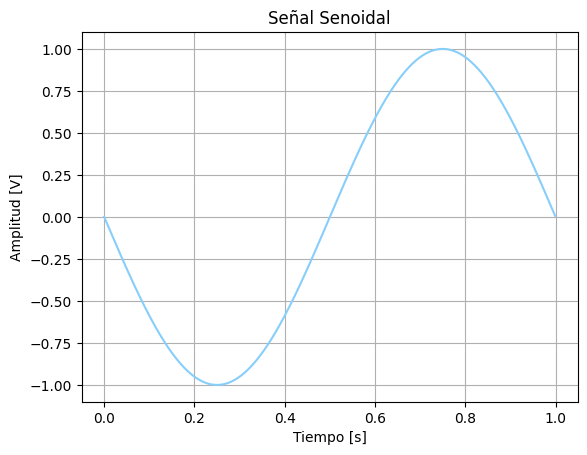

In [8]:
import matplotlib.pyplot as plt

plt.plot(tt, xx, color = 'lightskyblue') 
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal Senoidal")
plt.grid(True)
plt.show()



## Bonus: señal senoidal para distintas frecuencias

Según el teorema de Nyquist-Shannon, para que no haya solapamiento espectral al muestrear una señal, la frecuencia de la señal debe ser estrictamente menor a la mitad de la frecuencia de muestreo ($f_s$). A este límite se le llama frecuencia de Nyquist ($f_s/2$). 

Por lo tanto, para este caso donde la frecuencia de muestreo es de 1000 Hz, cualquier onda que tenga una frecuencia mayor a 500 Hz sufrirá un proceso irreversible de solapamiento espectral, también llamado fenómeno de aliasing, y, por lo tanto, no será observada verdaderamente en los gráficos. En cambio, se observará una frecuencia aparente, la cual equivale a la diferencia que existe entre la frecuencia real de la señal y el múltiplo más cercano a la frecuencia de muestreo. Entonces, para una señal de 1001 Hz, el múltiplo más cercano es 1000 Hz, es decir, una vez la frecuencia de muestreo. De la misma manera, para 2001 Hz, el múltiplo más cercano es 2000 Hz, es decir, dos veces la frecuencia de muestreo. 

Dejando todos los valores fijos excepto el de la frecuencia, se observarán diferentes gráficos para cada una de ellas.


### Experimento 1: frecuencia de 500 Hz

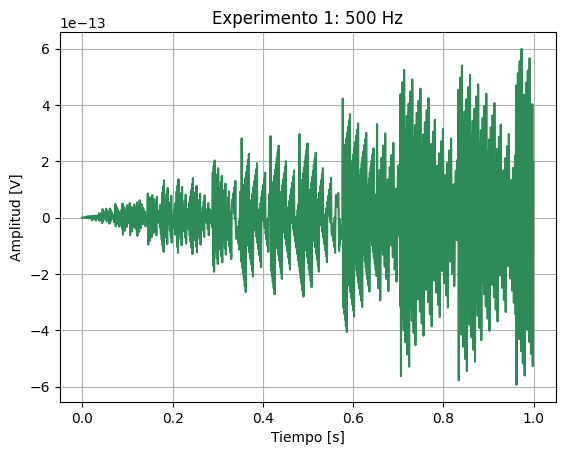

In [9]:
ff=500
tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)
plt.plot(tt, xx, color = 'seagreen') 
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Experimento 1: 500 Hz")
plt.grid(True)
plt.show()

Para este primer caso, la frecuencia de la señal es de 500 Hz y, por lo tanto, nos encontramos exactamente en el límite de Nyquist. Como las componentes espectrales se anulan mutuamente y como las muestras tomadas coinciden con los momentos en donde la señal se hace cero, se pueden observar en el gráfico valores muy pequeños de amplitud.

### Experimento 2: frecuencia de 999 Hz

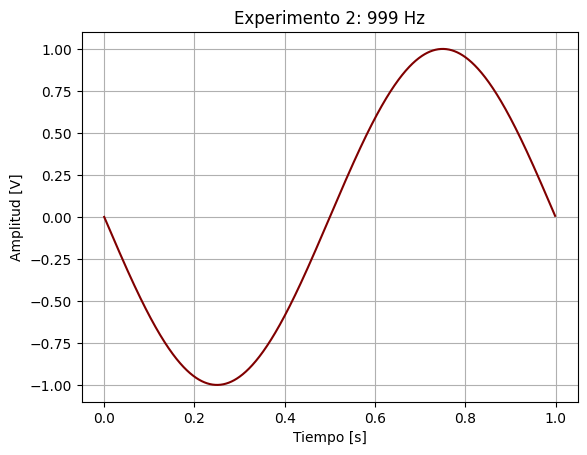

In [10]:
ff=999
tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)
plt.plot(tt, xx, color = 'maroon') 
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Experimento 2: 999 Hz")
plt.grid(True)
plt.show()

Para este segundo caso, la frecuencia real de la señal es de 999 Hz. Por lo que, el múltiplo de la frecuencia de muestreo más cercano es 1000 Hz, es decir, una vez la frecuencia de muestreo. Al tomar la diferencia entre estos valores, el resultado es una señal senoidal de 1 Hz invertida. 

### Experimento 3: frecuencia de 1001 Hz

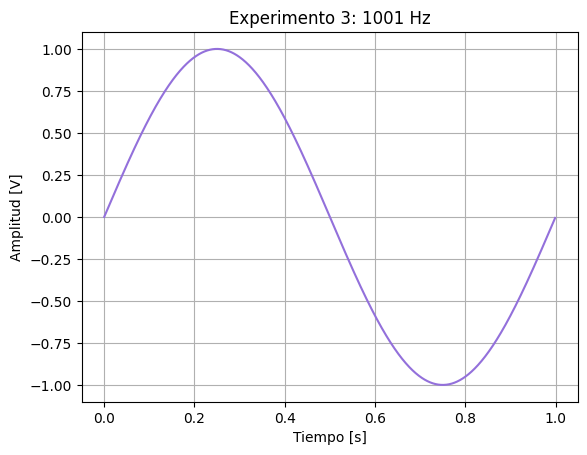

In [11]:
ff=1001
tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)
plt.plot(tt, xx, color = 'mediumpurple') 
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Experimento 3: 1001 Hz")
plt.grid(True)
plt.show()

Al incrementar la frecuencia a 1001 Hz, el múltiplo de la frecuencia de muestreo más cercano, nuevamente, es de 1000 Hz. A diferencia del caso anterior, como la frecuencia real supera a la de muestreo, la diferencia es positiva, dando como resultado una onda senoidal de 1 Hz, idéntica a la original.

### Experimento 4: frecuencia de 2001 Hz

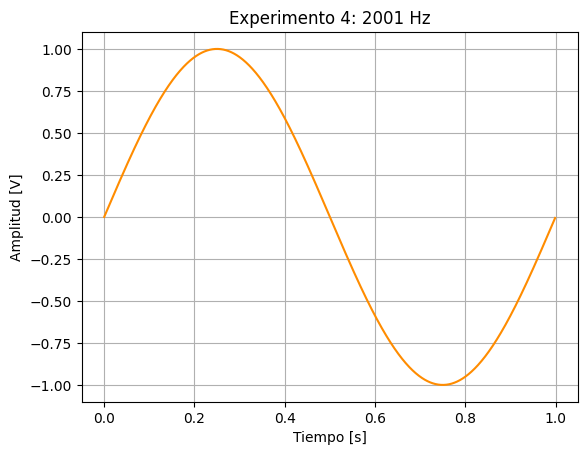

In [12]:
ff=2001
tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)
plt.plot(tt, xx, color = 'darkorange') 
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Experimento 4: 2001 Hz")
plt.grid(True)
plt.show()

Por último, para 2001 Hz obtenemos que el múltiplo más cercano de la frecuencia de muestreo pasa a ser 2000 Hz. Calculando la diferencia entre ambas frecuencias, se obtiene nuevamente una onda senoidal de 1 Hz.


## Muestreo de otro tipo de señal

Utilizando las librerías de SciPy, se pueden implementar [otro tipo de señales](https://docs.scipy.org/doc/scipy/reference/signal.html#waveforms), propias de un generador de señales. En este caso, la elegida fue la señal de onda cuadrada. 

Comenzamos nuevamente definiendo la función para la señal elegida y eligiendo los valores para cada variable dentro de ella. 

In [14]:
from scipy import signal # Agregamos libreria

def mi_funcion_cuadrada(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs # Tiempo entre cada muestra
    tt = np.arange(0, nn) * ts # Eje de tiempo
    xx = dc + vmax * signal.square(2 * np.pi * ff * tt + ph) 
    tt = tt.reshape(nn, 1) # Para asegurar que el tamaño sea de Nx1
    xx = xx.reshape(nn, 1) # Para asegurar que el tamaño sea de Nx1
    return tt, xx

vmax= 1 # Amplitud = 1
dc=0 # Valor medio
ff=1 # Frecuencia
ph=0 # Fase
nn=1000 # Cantidad de muestras
fs=1000 # Frecuencia de muestreo


Posteriormente, el gráfico de la señal se vería así:

In [ ]:
tt_cuadrada, xx_cuadrada = mi_funcion_cuadrada(vmax, dc, ff, ph, nn, fs)

plt.figure()
plt.plot(tt_cuadrada, xx_cuadrada, color='mediumseagreen')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal cuadrada")
plt.grid(True)
plt.show()

# Conclusión 

A partir de los gráficos previamente obtenidos, se puede observar cómo la señal de 500 Hz representa el caso límite donde $f_{s}/2$ = 500 Hz. Al coincidir los puntos donde la señal se anula con los puntos donde se toman las muestras, las componentes espectrales se anulan mutuamente, provocando una pérdida total de la amplitud de la señal. 

Por otro lado, las señales de 999 Hz, 1001 Hz y 2001 Hz sufren del fenómeno de aliasing debido a que superan el límite de Nyquist de 500 Hz. Al no tener una frecuencia de muestreo suficiente para capturar las oscilaciones reales, el sistema es incapaz de representarlas y reconstruye una frecuencia aparente pero mucho más lenta. Es por ello que, en estas tres señales previamente mencionadas, se adopta una forma visual de una onda de 1 Hz (en el caso de 999 Hz, con fase invertida).

Finalmente, en base a los resultados obtenidos, se demostró empíricamente la importancia de la elección de la frecuencia de muestreo debido a que, en caso de no respetar el teorema de Nyquist-Shannon, el sistema sufrirá un proceso irreversible, observándose una frecuencia aparente.